# Marketing A/B Testing Analysis
**Author:** Farhana Agufa

**Date:** 1st June 2026  

**Dataset:** Marketing A/B Testing (Kaggle - FavioVázquez)  

## Objective
To determine whether showing ads significantly increases 
customer conversions using a chi-square statistical test.

## 1. Introduction/Project Overview

### Background
In today's competitive marketplace, marketing companies 
invest significant resources in advertising campaigns for 
attraction and convertion. However, the 
market is complex and several campaign strategies and versions can work 
simultaneously, making it difficult to determine which 
approach delivers the maximum impact. To navigate this 
complexity, companies rely on data-driven decision making 
through a technique called A/B testing, which is a randomized 
experimentation process where two or more versions of a 
variable such as a web page, banner, or page element are 
shown to different segments of people at the same time. 
The goal is to identify which version drives the most 
engagement and business metrics.

### Problem Statement
This project seeks to answer two critical business questions 
that marketing companies face when evaluating their campaigns:

* Would the campaign be successful?
* If the campaign was successful, how much of that success 
  could be attributed to the ads?

To answer these questions, an A/B test was conducted where 
the majority of users were exposed to advertisements 
(the experimental group), while a smaller portion of users 
saw a Public Service Announcement or nothing at all 
(the control group) in the exact same size and placement 
where the ad would normally appear. The dataset captures 
key information about each user including their test group, 
whether they converted (made a purchase), the total number 
of ads seen, and the day and hour they were most exposed 
to ads.

### Approach
To address the business problem, this analysis will follow 
a structured data science workflow:

* **Data Loading & Exploration:** Load the dataset using 
  the Kaggle API and inspect its structure, size, data 
  types, and missing values
* **Data Cleaning:** Handle any inconsistencies or null 
  values to ensure the integrity of the analysis
* **Exploratory Data Analysis (EDA):** Visualize conversion 
  patterns across the ad and PSA groups, and examine 
  behavioral patterns such as the most active days and 
  hours of ad exposure
* **Hypothesis Testing:** Apply a chi-square statistical 
  test to determine whether the difference in conversion 
  rates between the experimental and control groups is 
  statistically significant
* **Business Insights:** Estimate the potential revenue 
  impact of the ads and provide actionable recommendations

### Expected Outcome
It is expected that users exposed to advertisements will 
show a significantly higher conversion rate compared to 
those who saw the PSA. If the chi-square test returns a 
p-value less than 0.05, we will reject the null hypothesis 
and conclude that the ads had a statistically significant 
effect on conversions, thus confirming that the campaign was 
successful and that the observed differences were not due 
to random chance. These findings will help the company 
make informed decisions about whether to scale the ad 
campaign and estimate the potential return on their 
advertising investment.

## 2. Environment Setup & API Configuration

### Kaggle API Authentication
Before loading the dataset, I authenticate 
with the Kaggle API using a personal access token. 
This token verifies my identity and grants permission 
to access Kaggle datasets programmatically from outside 
the Kaggle platform.

The API token is generated from the Kaggle platform 
under Settings → API Tokens → Generate New Token. 
Once generated, I copy the token and store directly 
as a variable in this notebook, then I pass to the 
Kaggle API configuration to establish a connection 
between this notebook and Kaggle.

**Note:** Never share your API token publicly as it is 
unique to your account and grants access to your 
Kaggle profile.

In [1]:
import os

# Create
os.makedirs(r'C:\Users\MAYKISH\.kaggle', exist_ok=True)

# Write your kaggle token
token = '{"username":"farhanapraxy","key":"KGAT_32fb12c3c58fb0b6b42472ae04c45385"}'

with open(r'C:\Users\MAYKISH\.kaggle\kaggle.json', 'w') as f:
    f.write(token)

print("Kaggle token saved successfully!")

Kaggle token saved successfully!


## 3. Import Libraries

In this section, I import all the necessary libraries 
required to execute this project. Each library serves 
a specific purpose in our analysis pipeline as from 
loading and manipulating data to visualizing patterns 
and conducting statistical tests.

### Libraries and Their Roles

**kagglehub**
I use kagglehub to establish a connection with the 
Kaggle REST API and download the Marketing A/B Testing 
dataset directly into my notebook environment without 
manually downloading any files.

**pandas**
I use pandas to load, manipulate and explore the 
dataset. It provides powerful data structures such as 
DataFrames that allow us to inspect, clean and 
transform our data efficiently.

**numpy**
I use numpy to perform numerical computations and 
handle array operations that support our data 
manipulation and statistical calculations throughout 
the analysis.

**matplotlib**
I use matplotlib to create basic visualizations such 
as bar charts and histograms that help us understand 
the distribution and patterns within the dataset.

**seaborn**
I use seaborn to create more advanced and visually 
appealing statistical plots that reveal relationships 
and patterns between the experimental and control 
groups in the dataset.

**scipy (chi2_contingency)**
I use the chi2_contingency function from scipy to 
conduct the chi-square statistical test which is the core 
of our hypothesis testing. This test determines 
whether the difference in conversion rates between 
the ad group and the PSA group is statistically 
significant or simply due to random chance.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

print("All libraries imported successfully!")

All libraries imported successfully!


## 4. Load Dataset

In this section, we use kagglehub to download the 
Marketing A/B Testing dataset directly from Kaggle 
through the REST API. The dataset is downloaded to 
a local cache folder on our computer. We then locate 
the CSV file within that folder and load it into a 
pandas DataFrame for analysis.

In [3]:
# Download dataset from Kaggle using REST API
path = kagglehub.dataset_download("faviovaz/marketing-ab-testing")

# Display download location
print(f"Dataset downloaded to: {path}")

# List all files in the downloaded folder
files = os.listdir(path)
print(f"Files available are: {files}")

# Load CSV file into pandas DataFrame
df = pd.read_csv(os.path.join(path, files[0]))

# Confirm successful loading
print(f"Dataset loaded successfully!")

Dataset downloaded to: C:\Users\MAYKISH\.cache\kagglehub\datasets\faviovaz\marketing-ab-testing\versions\1
Files available: ['marketing_AB.csv']
Dataset loaded successfully!


## 5. Data Exploration

In this section, I explore the structure and content 
of the Marketing A/B Testing dataset to gain a deeper 
understanding of its characteristics before proceeding 
to cleaning and analysis. Data exploration helps us 
identify potential issues such as missing values, 
duplicate records, inconsistent data and incorrect data types that could 
affect the integrity of our analysis.

In [5]:
# Display the first 5 rows of the dataset/ Inspecting data structure
print("The first 5 rows of the dataset:")
df.head()

The first 5 rows of the dataset:


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [6]:
# Check the size of the dataset/ Shape of data
print(f"The dataset has {df.shape[0]:,} rows and {df.shape[1]} columns")

The dataset has 588,101 rows and 7 columns


In [22]:
# Check the data types of each column
print("Column Data Types:")
print(df.dtypes)

Column Data Types:
Unnamed: 0       int64
user id          int64
test group         str
converted         bool
total ads        int64
most ads day       str
most ads hour    int64
dtype: object


In [7]:
# Check for missing values in each column
print("Total missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Total missing Values per Column:
Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

Total missing values: 0


In [8]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Total number of duplicate rows: {duplicates:,}")

Total number of duplicate rows: 0


In [9]:
# Generate summary statistics for numerical columns
print("Summary Statistics:")
df.describe()

Summary Statistics:


,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279668,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [10]:
# Check unique values in categorical columns
print(f"Unique values in 'test group': {df['test group'].unique()}")
print(f"Unique values in 'converted': {df['converted'].unique()}")
print(f"Unique values in 'most ads day': {df['most ads day'].unique()}")

Unique values in 'test group': <StringArray>
['ad', 'psa']
Length: 2, dtype: str
Unique values in 'converted': [False  True]
Unique values in 'most ads day': <StringArray>
['Monday', 'Tuesday', 'Friday', 'Saturday', 'Wednesday', 'Sunday', 'Thursday']
Length: 7, dtype: str


### Checking Numerical Column Data Types

In this step, I verify that all numerical columns 
contain the correct data types. Specifically, I check 
whether integer columns contain whole numbers (integers) 
and not decimal numbers (floats) to ensure data integrity 
before proceeding with my analysis.

In [12]:
# Check specifically numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(f"Numerical columns: {list(numerical_cols)}")
print()

# Check if any numerical column contains float values
for col in numerical_cols:
    is_integer = (df[col] == df[col].astype(int)).all()
    print(f"{col}: {'Integer values' if is_integer else 'Float values'}")

    

Numerical columns: ['Unnamed: 0', 'user id', 'total ads', 'most ads hour']

Unnamed: 0: Integer values
user id: Integer values
total ads: Integer values
most ads hour: Integer values


## 6. Data Cleaning

Based on our data exploration, the dataset is almost 
clean with no missing values, no duplicate records and 
no unnecessary columns. We perform one cleaning step 
to ensure the integrity of our analysis:

- **Step 1:** I verify that no unnecessary index column 
  exists in the dataset
- **Step 2:** I investigate and handle outliers in 
  the `total ads` column where the maximum value of 
  2,065 is significantly higher than the mean of 24.82, 
  suggesting the presence of extreme values that could 
  skew my analysis

In [13]:
# Confirm Unnamed: 0/index column is not present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Unnamed: 0 column dropped successfully!")
else:
    print("Unnamed: 0 column does not exist, then no action needed!")

# Display current columns
print(f"\nCurrent columns: {df.columns.tolist()}")
print(f"Total columns: {df.shape[1]}")
print(df.head())

Unnamed: 0 column dropped successfully!

Current columns: ['user id', 'test group', 'converted', 'total ads', 'most ads day', 'most ads hour']
Total columns: 6
   user id test group  converted  total ads most ads day  most ads hour
0  1069124         ad      False        130       Monday             20
1  1119715         ad      False         93      Tuesday             22
2  1144181         ad      False         21      Tuesday             18
3  1435133         ad      False        355      Tuesday             10
4  1015700         ad      False        276       Friday             14


### Handling Outliers in Total Ads Column

I investigate extreme values in the `total ads` column 
using the Interquartile Range (IQR) method, which is a standard 
statistical approach for detecting and handling outliers. 
Any value above the upper bound is considered an outlier 
and is removed to prevent it from skewing our analysis.

In [14]:
# Calculate outlier boundary using IQR method/ Investigate ouliers 
Q1 = df['total ads'].quantile(0.25)
Q3 = df['total ads'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)

print(f"Q1  (25th percentile): {Q1}")
print(f"Q3  (75th percentile): {Q3}")
print(f"IQR:                   {IQR}")
print(f"Upper Bound:           {upper_bound}")
print(f"Number of outliers:    {(df['total ads'] > upper_bound).sum():,}")
print(f"Percentage of data:    {(df['total ads'] > upper_bound).mean()*100:.2f}%")

Q1  (25th percentile): 4.0
Q3  (75th percentile): 27.0
IQR:                   23.0
Upper Bound:           61.5
Number of outliers:    52,057
Percentage of data:    8.85%


In [15]:
# Remove outliers above the upper bound
df_clean = df[df['total ads'] <= upper_bound]

# Confirm the result
print(f"Original dataset:  {df.shape[0]:,} rows")
print(f"Cleaned dataset:   {df_clean.shape[0]:,} rows")
print(f"Rows removed:      {df.shape[0] - df_clean.shape[0]:,} rows")
print(f"Data retained:     {df_clean.shape[0]/df.shape[0]*100:.2f}%")

Original dataset:  588,101 rows
Cleaned dataset:   536,044 rows
Rows removed:      52,057 rows
Data retained:     91.15%


In [16]:
# Final confirmation
print("Final Cleaned Dataset Summary:")
print(f"Shape:          {df_clean.shape[0]:,} rows and {df_clean.shape[1]} columns")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"Duplicates:     {df_clean.duplicated().sum()}")
print(f"\nTotal Ads statistics after cleaning:")
print(df_clean['total ads'].describe())


Final Cleaned Dataset Summary:
Shape:          536,044 rows and 6 columns
Missing values: 0
Duplicates:     0

Total Ads statistics after cleaning:
count    536044.000000
mean         15.134015
std          14.063618
min           1.000000
25%           4.000000
50%          11.000000
75%          22.000000
max          61.000000
Name: total ads, dtype: float64


In [17]:
df_clean.describe()


,user id,total ads,most ads hour
count,5.360440e+05,536044.000000,536044.000000
mean,1.310161e+06,15.134015,14.475189
std,2.022666e+05,14.063618,4.834794
min,9.000000e+05,1.000000,0.000000
25%,1.142207e+06,4.000000,11.000000
50%,1.312828e+06,11.000000,14.000000
75%,1.483732e+06,22.000000,18.000000
max,1.654483e+06,61.000000,23.000000


## 7. Visualizations

In this section, I create visualizations to explore 
patterns and relationships within the cleaned dataset. 
Each visualization helps us understand the distribution 
of users across groups, conversion behavior and the 
impact of ad exposure timing on conversions. These 
visual insights guide our hypothesis testing and 
support our final conclusions.

### 7.1 Distribution of Test Groups
I visualize distribution of users across the 
experimental group (ad) and control group (psa) to 
confirm that the majority of users were exposed to 
advertisements as expected in the A/B test design.

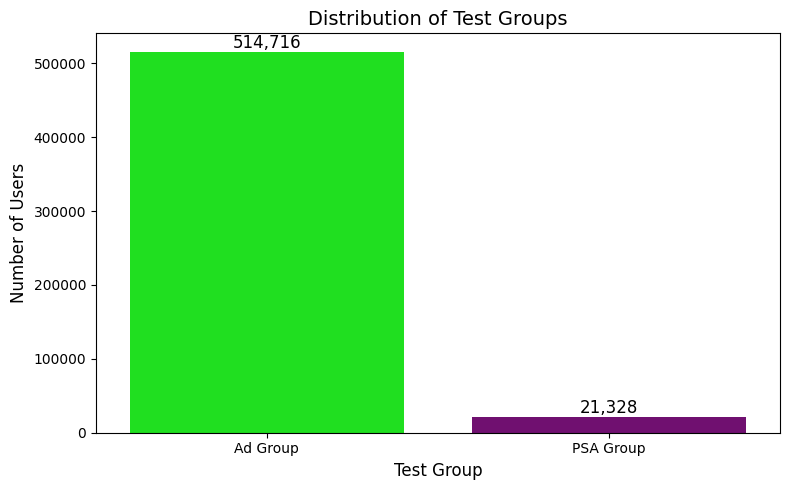

test group
ad     514716
psa     21328
Name: count, dtype: int64

Percentage split:
test group
ad     96.021222
psa     3.978778
Name: proportion, dtype: float64


In [36]:
# Create a canvas with dimensions
plt.figure(figsize=(8, 5))

# Draw the chart
ax = sns.countplot(data=df_clean, x='test group', 
                   palette=['#00FF00', '#800080'])

# Add value labels/numbers on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', 
                (p.get_x() + p.get_width() / 2., 
                p.get_height()),
                ha='center', va='bottom', fontsize=12)

# Add title, axes, group labels
plt.title('Distribution of Test Groups', fontsize=14)
plt.xlabel('Test Group', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Ad Group', 'PSA Group'])

plt.tight_layout()
plt.show()

# Print exact counts
print(df_clean['test group'].value_counts())
print(f"\nPercentage split:")
print(df_clean['test group'].value_counts(normalize=True)*100)

### 7.2 Conversion Rate by Test Group

I compare the conversion rates between the ad group 
and PSA group to visually assess whether users exposed 
to advertisements are more likely to make a purchase 
than those who saw the public service announcement. 
Conversion rate is calculated as the percentage of 
users who made a purchase within each group.

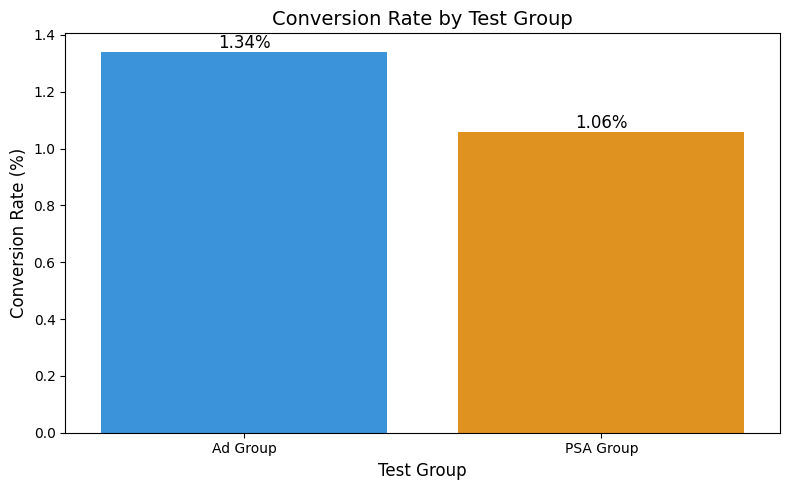

Conversion Rates:
Ad Group:  1.34%
PSA Group: 1.06%

Difference: 0.28%


In [38]:
# Calculate conversion rate by test group
conversion_rate = df_clean.groupby('test group')['converted'].mean() * 100

# Create a canvas with dimensions
plt.figure(figsize=(8, 5))

# Draw the chart
ax = sns.barplot(x=conversion_rate.index, 
                 y=conversion_rate.values,
                 palette=['#2196F3', '#FF9800'])

# Add value labels/rate on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2.,
                p.get_height()),
                ha='center', va='bottom', fontsize=12)

# Add title, axes, group labels
plt.title('Conversion Rate by Test Group', fontsize=14)
plt.xlabel('Test Group', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Ad Group', 'PSA Group'])
plt.tight_layout()
plt.show()

# Print exact conversion rates
print("Conversion Rates:")
print(f"Ad Group:  {conversion_rate['ad']:.2f}%")
print(f"PSA Group: {conversion_rate['psa']:.2f}%")
print(f"\nDifference: {conversion_rate['ad'] - conversion_rate['psa']:.2f}%")

### 7.3 Total Ads Distribution

I examine the distribution of total ads seen by users 
in the cleaned dataset to understand the typical ad 
exposure pattern. This helps us confirm that our 
outlier removal was effective and that the remaining 
data represents a realistic range of ad exposure 
for most users.

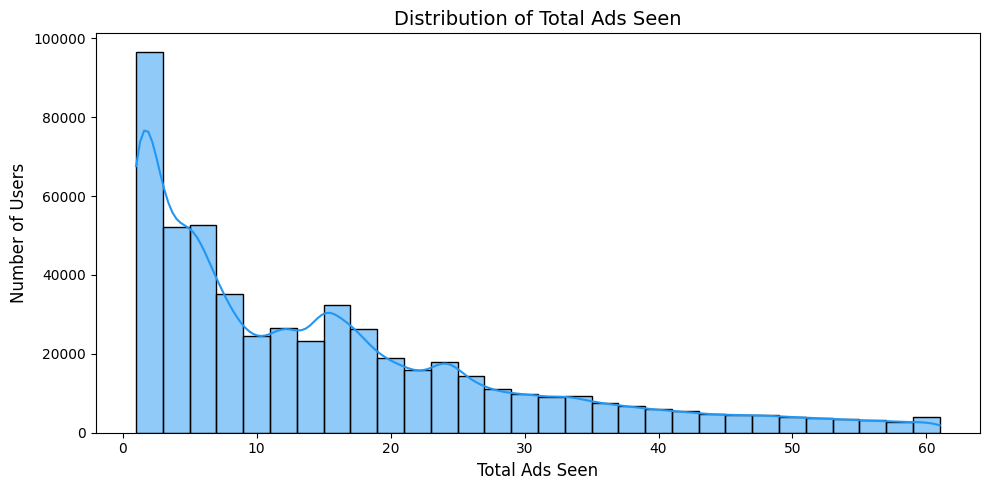

Total Ads Distribution Summary:
Mean:   15.13 ads
Median: 11.00 ads
Min:    1 ads
Max:    61 ads


In [39]:
# Create a canvas with dimensions
plt.figure(figsize=(10, 5))

# Draw the chart
sns.histplot(data=df_clean, x='total ads', 
             bins=30, color='#2196F3', kde=True)

# Add title, axes, group labels
plt.title('Distribution of Total Ads Seen', fontsize=14)
plt.xlabel('Total Ads Seen', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.tight_layout()
plt.show()

# Print summary statistics
print("Total Ads Distribution Summary:")
print(f"Mean:   {df_clean['total ads'].mean():.2f} ads")
print(f"Median: {df_clean['total ads'].median():.2f} ads")
print(f"Min:    {df_clean['total ads'].min():.0f} ads")
print(f"Max:    {df_clean['total ads'].max():.0f} ads")

### 7.4 Conversions by Day of Week

I examine which days of the week generate the highest 
number of conversions to identify optimal days for 
ad exposure. This insight helps the marketing company 
understand when their target audience is most receptive 
to advertisements and most likely to make a purchase.

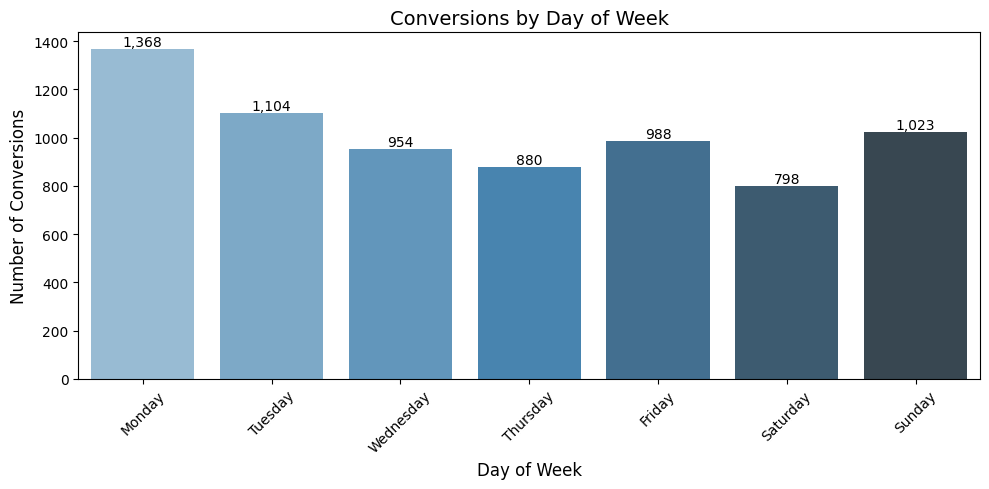

Conversions by Day:
Monday: 1,368
Tuesday: 1,104
Wednesday: 954
Thursday: 880
Friday: 988
Saturday: 798
Sunday: 1,023


In [40]:
# Define correct day order
day_in_a_week = ['Monday', 'Tuesday', 'Wednesday', 
             'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate conversions by day
conversions_by_day = df_clean[df_clean['converted'] == True]\
                    .groupby('most ads day')['converted']\
                    .count().reindex(day_in_a_week)

# Create a canvas with dimensions
plt.figure(figsize=(10, 5))

# Draw the chart
ax = sns.barplot(x=conversions_by_day.index, 
                 y=conversions_by_day.values,
                 palette='Blues_d')

# Add value labels/numbers on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2.,
                p.get_height()),
                ha='center', va='bottom', fontsize=10)

# Add title, axes, group labels
plt.title('Conversions by Day of Week', fontsize=14)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Number of Conversions', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print exact values
print("Conversions by Day:")
for day, count in zip(conversions_by_day.index, 
                      conversions_by_day.values):
    print(f"{day}: {count:,}")

### 7.5 Conversions by Hour of Day

I examine which hours of the day generate the highest 
number of conversions to identify the optimal timing 
for ad exposure. This insight helps the marketing 
company schedule their advertisements during peak 
hours when users are most receptive and most likely 
to make a purchase.

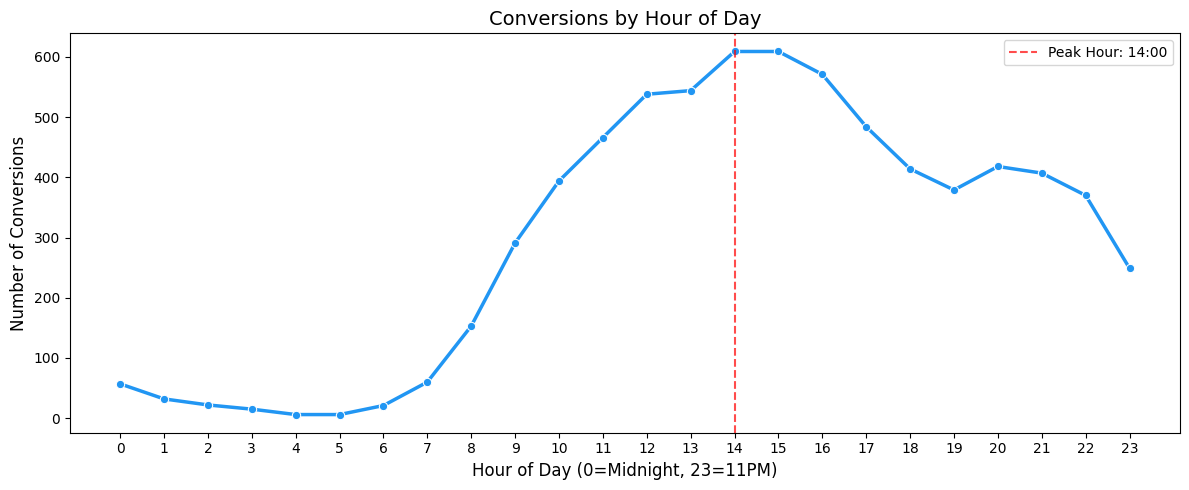

Top 5 Peak Hours for Conversions:
most ads hour
14    609
15    609
16    571
13    544
12    538
Name: converted, dtype: int64

Best hour to show ads: 14:00
Conversions at peak:   609


In [41]:
# Calculate conversions by hour
conversions_by_hour = df_clean[df_clean['converted'] == True]\
                     .groupby('most ads hour')['converted']\
                     .count()

# Create a canvas with dimensions
plt.figure(figsize=(12, 5))

# Draw the chart
ax = sns.lineplot(x=conversions_by_hour.index,
                  y=conversions_by_hour.values,
                  color='#2196F3', linewidth=2.5,
                  marker='o', markersize=6)

# Highlight peak hour
peak_hour = conversions_by_hour.idxmax()
peak_value = conversions_by_hour.max()
plt.axvline(x=peak_hour, color='red', 
            linestyle='--', alpha=0.7,
            label=f'Peak Hour: {peak_hour}:00')

# Add title, axes, group labels
plt.title('Conversions by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (0=Midnight, 23=11PM)', fontsize=12)
plt.ylabel('Number of Conversions', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

# Print peak hours
print("Top 5 Peak Hours for Conversions:")
print(conversions_by_hour.nlargest(5))
print(f"\nBest hour to show ads: {peak_hour}:00")
print(f"Conversions at peak:   {peak_value:,}")

## 8. Hypothesis Testing

In this section, I conduct a chi-square statistical 
test to determine whether the difference in conversion 
rates between the ad group and the PSA group is 
statistically significant. Statistical significance 
tells us whether the observed difference is real or 
simply due to random chance.

### Hypotheses
- **Null Hypothesis (H0):** There is no significant 
  difference in conversion rates between the ad group 
  and the PSA group. Any observed difference is due 
  to random chance.
- **Alternative Hypothesis (H1):** There is a 
  significant difference in conversion rates between 
  the ad group and the PSA group. The ads have a 
  real impact on conversions.

### Significance Level
I use a significance level of **α = 0.05** meaning 
I require 95% confidence before rejecting the 
null hypothesis.

In [42]:
# Create contingency table
contingency_table = pd.crosstab(
    df_clean['test group'],
    df_clean['converted']
)

print("Contingency Table:")
print(contingency_table)
print(f"\nRows: Test Group (ad/psa)")
print(f"Columns: Converted (False/True)")

Contingency Table:
converted    False  True 
test group               
ad          507827   6889
psa          21102    226

Rows: Test Group (ad/psa)
Columns: Converted (False/True)


In [43]:
# Run chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("=" * 45)
print("       CHI-SQUARE TEST RESULTS")
print("=" * 45)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value:              {p_value:.4f}")
print(f"Degrees of Freedom:   {dof}")
print("=" * 45)

       CHI-SQUARE TEST RESULTS
Chi-Square Statistic: 11.9396
P-Value:              0.0005
Degrees of Freedom:   1


In [44]:
# Results Interpretation
# Significance level
alpha = 0.05

print("=" * 45)
print("         INTERPRETATION")
print("=" * 45)
print(f"Significance Level:   {alpha}")
print(f"P-Value:              {p_value:.4f}")
print("-" * 45)

if p_value < alpha:
    print("RESULT: REJECT Null Hypothesis")
    print("-" * 45)
    print("Conclusion:")
    print("The difference in conversion rates")
    print("between the ad group and PSA group")
    print("IS statistically significant.")
    print("Ads DO have a real impact on")
    print("customer conversions!")
else:
    print("RESULT: FAIL TO REJECT Null Hypothesis")
    print("-" * 45)
    print("Conclusion:")
    print("The difference in conversion rates")
    print("between the ad group and PSA group")
    print("is NOT statistically significant.")
    print("Ads DO NOT have a proven impact on")
    print("customer conversions.")

print("=" * 45)

         INTERPRETATION
Significance Level:   0.05
P-Value:              0.0005
---------------------------------------------
RESULT: REJECT Null Hypothesis
---------------------------------------------
Conclusion:
The difference in conversion rates
between the ad group and PSA group
IS statistically significant.
Ads DO have a real impact on
customer conversions!


In [45]:
# Compare observed vs expected values
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("Observed Values:")
print(contingency_table)
print(f"\nExpected Values (if no relationship):")
print(expected_df.round(2))
print(f"\nDifference (Observed - Expected):")
print((contingency_table - expected_df).round(2))

Observed Values:
converted    False  True 
test group               
ad          507827   6889
psa          21102    226

Expected Values (if no relationship):
converted       False    True 
test group                    
ad          507884.09  6831.91
psa          21044.91   283.09

Difference (Observed - Expected):
converted   False  True 
test group              
ad         -57.09  57.09
psa         57.09 -57.09


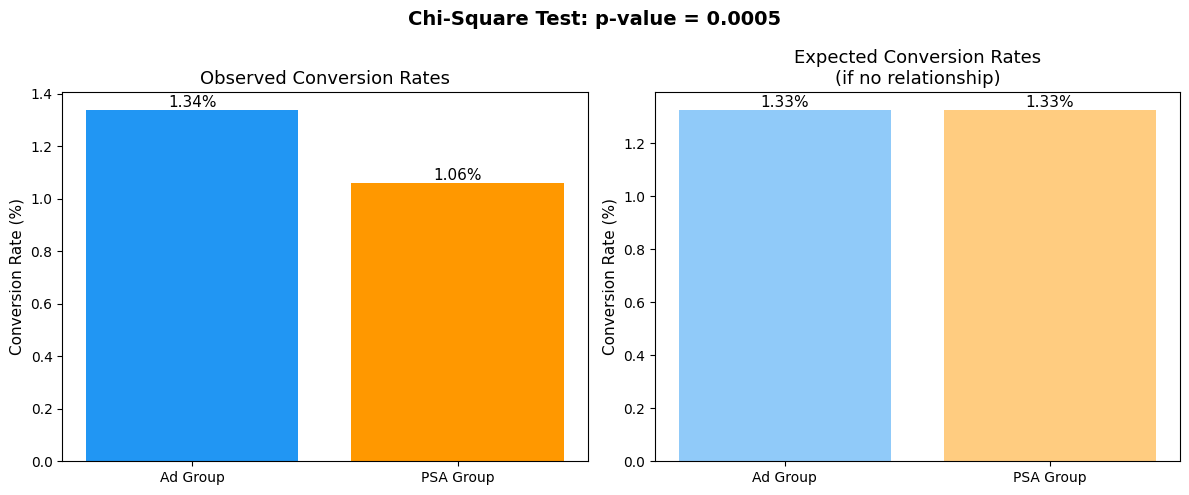

In [46]:
# Visualize Chi Square results
# Visualize observed vs expected conversions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Observed conversions
observed_rates = df_clean.groupby(
    'test group')['converted'].mean() * 100
axes[0].bar(
    ['Ad Group', 'PSA Group'],
    observed_rates.values,
    color=['#2196F3', '#FF9800']
)
axes[0].set_title('Observed Conversion Rates', fontsize=13)
axes[0].set_ylabel('Conversion Rate (%)', fontsize=11)
for i, v in enumerate(observed_rates.values):
    axes[0].text(i, v, f'{v:.2f}%',
                ha='center', va='bottom', fontsize=11)

# Expected conversions
expected_rates = [
    expected_df.loc['ad', True] / 
    contingency_table.loc['ad'].sum() * 100,
    expected_df.loc['psa', True] / 
    contingency_table.loc['psa'].sum() * 100
]
axes[1].bar(
    ['Ad Group', 'PSA Group'],
    expected_rates,
    color=['#90CAF9', '#FFCC80']
)
axes[1].set_title(
    'Expected Conversion Rates\n(if no relationship)',
    fontsize=13
)
axes[1].set_ylabel('Conversion Rate (%)', fontsize=11)
for i, v in enumerate(expected_rates):
    axes[1].text(i, v, f'{v:.2f}%',
                ha='center', va='bottom', fontsize=11)

plt.suptitle(
    f'Chi-Square Test: p-value = {p_value:.4f}',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 9. Conclusions

### Summary of Findings

This project analyzed the Marketing A/B Testing dataset 
to determine whether advertising campaigns significantly 
increase customer conversion rates compared to showing 
a Public Service Announcement.

### Key Findings

**1. Dataset Overview**
After cleaning, the dataset contained 536,044 users 
split across two groups — 514,716 users in the ad group 
(96.02%) and 21,328 users in the PSA group (3.98%).

**2. Conversion Rates**
The ad group achieved a conversion rate of 1.34% 
compared to 1.06% for the PSA group, with a difference 
of 0.28% in favor of the ad group.

**3. Statistical Test**
The chi-square test returned a chi-square statistic 
of 11.9396 and a p-value of 0.0005, which is far below our 
significance level of 0.05. We therefore reject the 
null hypothesis and conclude that ads have a 
statistically significant impact on conversions.

**4. Timing Insights**
Analysis revealed that Monday generates the highest 
number of conversions (1,368) while Saturday generates 
the lowest (798). The peak hours for conversions are 
2:00 PM and 3:00 PM with 609 conversions each.

### Business Recommendations

| Recommendation | Action |
|---|---|
| Continue running ads | Campaign is statistically proven to work |
| Focus on Mondays | Highest conversion day |
| Schedule ads 12PM - 4PM | Peak conversion window |
| Reduce Saturday spend | Lowest conversion day |
| Avoid overnight ads | 3AM - 7AM very low conversions |

### Final Verdict
The advertising campaign is **successful** and the 
observed difference in conversion rates between the 
ad group and PSA group is **not due to random chance**. 
The company can confidently invest in and scale this 
advertising campaign to drive further business growth.